In [1]:
!pip install ruptures


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00


#Module 3
###Introduction to E-Portfolio Complex Systems

###Lecture 3: Properties of Complex Dynamical Systems


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder


from statsmodels.tsa.stattools import kpss


import ruptures as rpt


In [3]:
df = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv')

In [4]:
df.describe()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [6]:
df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,2067
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [7]:
df['pm2.5'] = df['pm2.5'].interpolate(method='linear')
df['pm2.5'].fillna(df['pm2.5'].mean(), inplace=True)
df['pm2.5'].isna().sum()

/tmp/ipykernel_3979/2028733723.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pm2.5'].fillna(df['pm2.5'].mean(), inplace=True)


np.int64(0)

In [8]:
# @title Labelencoding cbwd

le = LabelEncoder()
le.fit(['NW', 'cv', 'NE', 'SE'])

'''
NW (North-West)   --> 0
cv (Clear)        --> 1
NE (North-East)   --> 2
SE (South-East)   --> 3
'''
df['cbwd'] = le.transform(df['cbwd'])


# RQs
  ###### - In what ways does the system manage the problem of complexity of substance and problem of pattern complexity?

  ###### - Does the system being studied exhibit a bifurcation?
  ###### - Does the data exhibit complex dynamics? And, what are the scientific and practical implications of that?



# Question 1:

#### In what ways does the system manage the problem of complexity of substance and problem of pattern complexity?

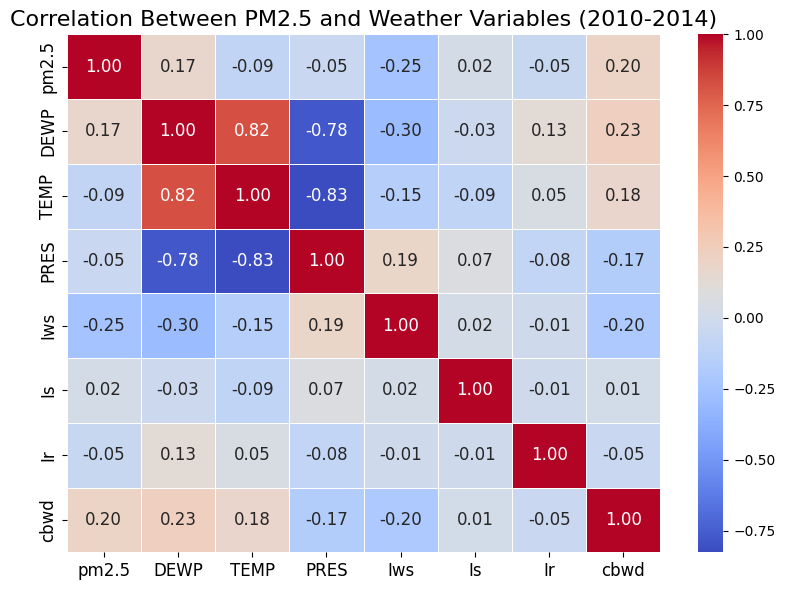

In [ ]:
# @title Correlation Matrix
dataframe = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd']]
corr_matrix = dataframe.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 12})
plt.title('Correlation Between PM2.5 and Weather Variables (2010-2014)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('module3_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

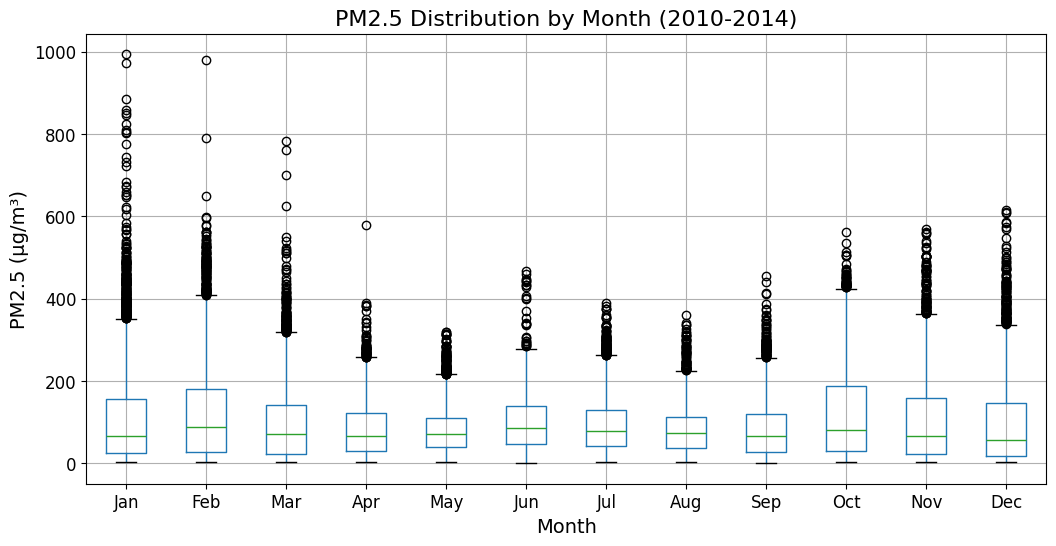

In [ ]:
# @title Pattern complexity

plt.figure(figsize=(12,6))
df.boxplot(column='pm2.5', by='month', figsize=(12,6))
plt.suptitle('')
plt.xlabel('Month', fontsize=14)
plt.ylabel('PM2.5 (µg/m³)', fontsize=14)
plt.title('PM2.5 Distribution by Month (2010-2014)', fontsize=16)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Module3_pm25_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

# Question 2

#### Does the system being studied exhibit a bifurcation?

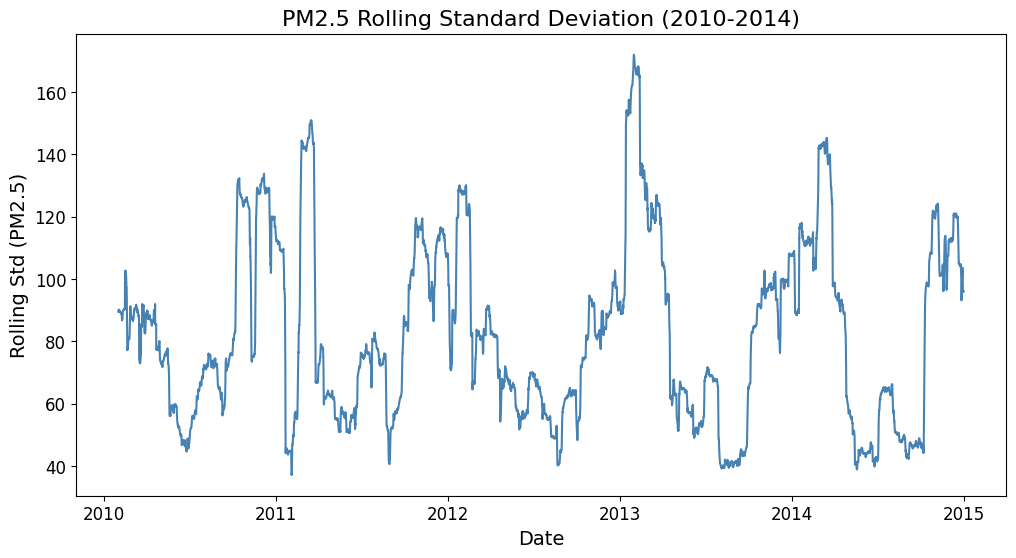

In [ ]:
# Rolling variance to show instability/bifurcation-like behavior
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
rolling_var = df['pm2.5'].rolling(window=720).std()

plt.figure(figsize=(12,6))
plt.plot(df['datetime'], rolling_var, color='steelblue')
plt.title('PM2.5 Rolling Standard Deviation (2010-2014)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Rolling Std (PM2.5)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('module3_pm25_rolling_std.png', dpi=300, bbox_inches='tight')
plt.show()

# Question 3

#### Does the data exhibit complex dynamics? And, what are the scientific and practical implications of that?

In [ ]:
# @title KPSS test on PM2.5
kpss_stat, p_value, lags, crit_values = kpss(df['pm2.5'].dropna(), regression='c', nlags='auto')

print(f'KPSS Statistic: {kpss_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Lags: {lags}')
print('Critical Values:')
for key, value in crit_values.items():
    print(f'   {key}: {value:.4f}')

KPSS Statistic: 0.0772
p-value: 0.1000
Lags: 114
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/tmp/ipykernel_8559/3939669554.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, lags, crit_values = kpss(df['pm2.5'].dropna(), regression='c', nlags='auto')


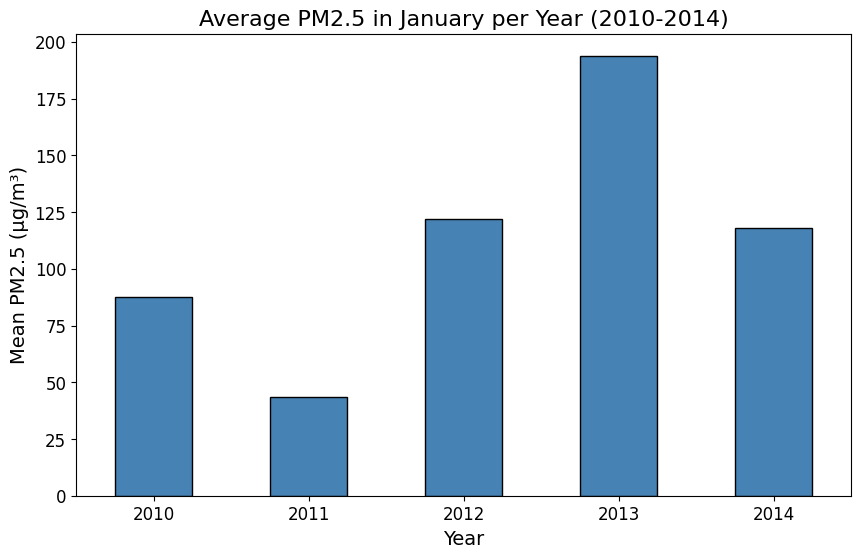

In [ ]:
# Filter January across all years
jan_data = df[df['month'] == 1]
jan_mean = jan_data.groupby('year')['pm2.5'].mean()

plt.figure(figsize=(10,6))
jan_mean.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average PM2.5 in January per Year (2010-2014)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Mean PM2.5 (µg/m³)', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('module3_january_barchart.png', dpi=300, bbox_inches='tight')
plt.show()